# Indonesia Temperature Forecast — BMKG + LightGBM

**Objective:** forecast hourly temperature 14 days ahead for Indonesian cities, validated with rollback (walk-forward) testing so accuracy reflects real forecasting, not hindsight.
**Method:** direct multi-horizon LightGBM — one model predicts every hour from T0+1h to T0+336h at once, using only information known at/before the origin T0. Library code lives in `code/`; this notebook orchestrates it step by step.

In [1]:
# import subprocess, sys
#
# packages = [
#     "lightgbm", "pandas", "numpy", "matplotlib",
#     "scikit-learn", "requests", "pyarrow", "joblib"
# ]
# for pkg in packages:
#     subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

## STEP 01 - Imports and Configuration

In [2]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Image, HTML

warnings.filterwarnings("ignore")

CODE_DIR = "code"
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

CONFIG = {
    "END_TRAIN":         None,
    "TARGET_DATE":       None,
    "STATIONS":          ["Jakarta"],

    "HISTORICAL_START":  "2019-01-01",
    "FORCE_REFRESH":     False,
    "SAVE_MODEL":        True,
    "SHOW_PLOTS":        False,
    "OUTPUT_DIR":        "result",

    "ORIGIN_STRIDE_HOURS":        24,
    "FORECAST_HORIZON_HOURS":     336,
    "TRAIN_BACKTEST_BUFFER_DAYS": 45,
    "LIVE_ORIGIN":       None,
}
os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

print("Configuration:")
for k, v in CONFIG.items():
    print(f"   {k:28s}: {v}")

Configuration:
   END_TRAIN                   : None
   TARGET_DATE                 : None
   STATIONS                    : ['Jakarta']
   HISTORICAL_START            : 2019-01-01
   FORCE_REFRESH               : False
   SAVE_MODEL                  : True
   SHOW_PLOTS                  : False
   OUTPUT_DIR                  : result
   ORIGIN_STRIDE_HOURS         : 24
   FORECAST_HORIZON_HOURS      : 336
   TRAIN_BACKTEST_BUFFER_DAYS  : 45
   LIVE_ORIGIN                 : None


## STEP 02 - Fetch Data (BMKG + Open-Meteo)

Historical hourly temperature from Open-Meteo (ERA5, since 2019); short-term forecast from BMKG. Cached to `data/*.parquet`.

In [3]:
from data_fetcher import fetch_all_stations, STATIONS

raw_data = fetch_all_stations(
    stations         = {k: v for k, v in STATIONS.items() if k in CONFIG["STATIONS"]},
    historical_start = CONFIG["HISTORICAL_START"],
    force_refresh    = CONFIG["FORCE_REFRESH"],
)

print("Data summary:")
print("-" * 70)
for name, df in raw_data.items():
    if df.empty:
        print(f"  !  {name}: EMPTY")
    else:
        src_counts = df["source"].value_counts().to_dict() if "source" in df.columns else {}
        print(f"  ok {name}: {len(df):,} rows | "
              f"{df['timestamp'].min().date()} -> {df['timestamp'].max().date()} | "
              f"Source: {src_counts}")
print("-" * 70)

2026-08-30 11:41:36,362 - INFO - [Cache] Loading Jakarta dari data\jakarta_raw.parquet


Data summary:
----------------------------------------------------------------------
  ok Jakarta: 64,147 rows | 2019-01-01 -> 2026-05-04 | Source: {'openmeteo_historical': 64128, 'bmkg_forecast': 19}
----------------------------------------------------------------------


,timestamp,temperature,humidity,wind_speed,source
64137,2026-05-03 20:00:00,26.0,91.0,3.5,bmkg_forecast
64138,2026-05-03 23:00:00,25.0,93.0,1.8,bmkg_forecast
64139,2026-05-04 02:00:00,25.0,95.0,1.9,bmkg_forecast
64140,2026-05-04 05:00:00,24.0,96.0,3.4,bmkg_forecast
64141,2026-05-04 08:00:00,28.0,82.0,3.4,bmkg_forecast
64142,2026-05-04 11:00:00,29.0,76.0,5.4,bmkg_forecast
64143,2026-05-04 14:00:00,28.0,80.0,5.4,bmkg_forecast
64144,2026-05-04 17:00:00,26.0,91.0,4.8,bmkg_forecast
64145,2026-05-04 20:00:00,25.0,92.0,4.8,bmkg_forecast
64146,2026-05-04 23:00:00,25.0,94.0,4.3,bmkg_forecast


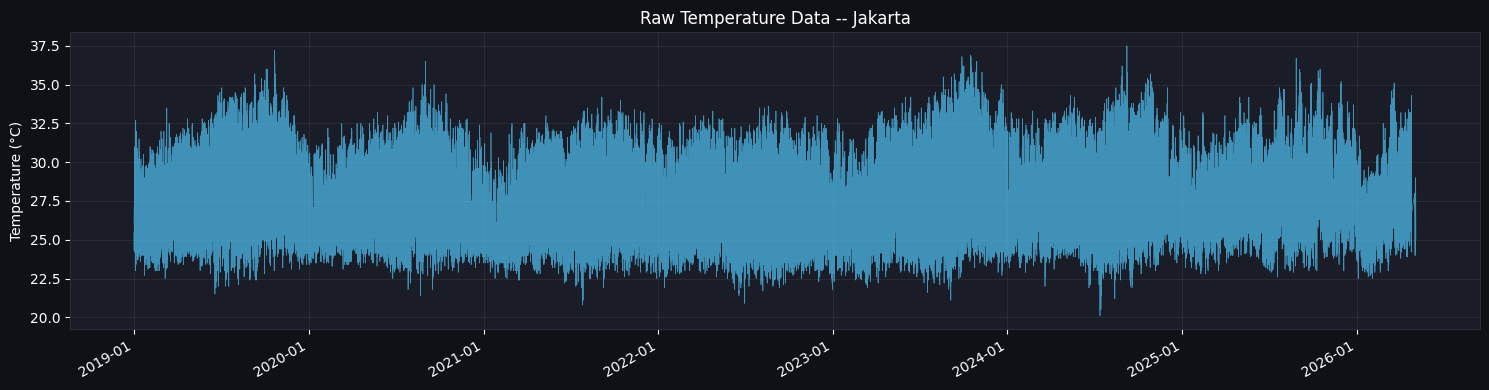

In [4]:
first_station = CONFIG["STATIONS"][0]
df_raw_sample = raw_data[first_station]

display(df_raw_sample[["timestamp", "temperature", "humidity", "wind_speed", "source"]].tail(10))

fig, ax = plt.subplots(figsize=(15, 4), facecolor="#0f1117")
ax.set_facecolor("#1a1d27")
ax.plot(df_raw_sample["timestamp"], df_raw_sample["temperature"],
        color="#4fc3f7", lw=0.5, alpha=0.7)
ax.set_title(f"Raw Temperature Data -- {first_station}", color="white")
ax.set_ylabel("Temperature (°C)", color="white")
ax.tick_params(colors="white")
ax.spines[:].set_color("#2a2d3a")
ax.grid(True, alpha=0.15, color="gray")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/{first_station.lower()}_raw_data.png", dpi=120, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

## STEP 03 - Resolve Forecast Origin Window

`END_TRAIN`: origins up to this date train the model. `TARGET_DATE`: origins between `END_TRAIN` and `TARGET_DATE - 14d` form the rollback backtest. Both resolve automatically from the latest fetched data when left `None`.

In [5]:
from main_bmkg_forecast import resolve_dates, validate_dates

end_train, target_date = resolve_dates(
    raw_data,
    CONFIG["END_TRAIN"], CONFIG["TARGET_DATE"], CONFIG["TRAIN_BACKTEST_BUFFER_DAYS"],
)
validate_dates(end_train, target_date, CONFIG["FORECAST_HORIZON_HOURS"])
CONFIG["END_TRAIN"], CONFIG["TARGET_DATE"] = end_train, target_date

print(f"END_TRAIN   : {end_train}   (training origins up to here)")
print(f"TARGET_DATE : {target_date}   (backtest window ends here)")

2026-08-30 11:41:38,684 - INFO - Period: train origins <= 2026-03-20 | backtest origins 2026-03-20 -> 2026-05-04 (horizon 336h)


END_TRAIN   : 2026-03-20   (training origins up to here)
TARGET_DATE : 2026-05-04   (backtest window ends here)


## STEP 04 - Feature Engineering

| Category | Features | Anchored to |
|---|---|---|
| Origin state | temperature lags (1-72h), rolling mean/std/min/max (7-90d), momentum, humidity/wind/precipitation | Data <= T0 |
| Target calendar | sin/cos hour, day-of-week/month, month, day-of-year, is_weekend, is_rainy_season | Target timestamp (always knowable) |
| Horizon | `horizon_h` (1-336) | -- |
| Climatology | historical mean/std per (month, day), from data <= END_TRAIN | Target's (month, day) |

Same-timestamp weather and target-relative lags are excluded since they aren't knowable days in advance.

In [6]:
from preprocessing import run_preprocessing, get_feature_columns

processed_data = {}

for name, df_raw in raw_data.items():
    if df_raw.empty:
        print(f"  !  {name}: skipped (empty data)")
        continue
    df_proc = run_preprocessing(df_raw, station_name=name, drop_na=True)
    processed_data[name] = df_proc
    print(f"  ok  {name}: {len(df_proc):,} origin rows | {len(get_feature_columns(df_proc))} state features")

first_station  = CONFIG["STATIONS"][0]
df_proc_sample = processed_data[first_station]
feat_cols      = get_feature_columns(df_proc_sample)

print(f"\nOrigin-state features for {first_station}: {len(feat_cols)}")
display(df_proc_sample[["timestamp", "temperature",
                          "lag_24h", "roll_mean_7d",
                          "momentum_24h", "humidity_at_origin"]].tail(5))

2026-08-30 11:41:38,750 - INFO - [Preprocessing] Starting for station: Jakarta | initial rows: 64147


2026-08-30 11:41:38,826 - INFO - Resampled to hourly: 64344 rows.


2026-08-30 11:41:39,013 - INFO - [Preprocessing] Done: 63060/64344 valid origin rows.


  ok  Jakarta: 63,060 origin rows | 38 state features

Origin-state features for Jakarta: 38


,timestamp,temperature,lag_24h,roll_mean_7d,momentum_24h,humidity_at_origin
63055,2026-04-26 07:00:00,26.748148,26.9,28.458433,-0.151852,91.0
63056,2026-04-26 08:00:00,26.748148,28.6,28.462886,-1.851852,91.0
63057,2026-04-26 09:00:00,26.748148,30.5,28.456030,-3.751852,91.0
63058,2026-04-26 10:00:00,26.748148,32.0,28.437864,-5.251852,91.0
63059,2026-04-26 11:00:00,26.748148,33.2,28.413150,-6.451852,91.0


## STEP 05 - Build Training / Backtest / Live Datasets

Each origin expands to up to `FORECAST_HORIZON_HOURS` rows (one per hour ahead). Training origins run up to `END_TRAIN`; backtest origins run from `END_TRAIN` to `TARGET_DATE - 14d`; the live origin is the latest available data.

In [7]:
from preprocessing import select_origins, build_climatology, build_direct_horizon_frame, TARGET_COL

datasets = {}
backtest_end = pd.to_datetime(CONFIG["TARGET_DATE"]) - pd.Timedelta(hours=CONFIG["FORECAST_HORIZON_HOURS"])

for name, df_state in processed_data.items():
    df_actual = df_state[["timestamp", TARGET_COL]].copy()
    clim = build_climatology(df_actual, as_of=CONFIG["END_TRAIN"])

    train_origins    = select_origins(df_state, end=CONFIG["END_TRAIN"], stride_hours=CONFIG["ORIGIN_STRIDE_HOURS"])
    backtest_origins = select_origins(df_state, start=CONFIG["END_TRAIN"], end=backtest_end, stride_hours=CONFIG["ORIGIN_STRIDE_HOURS"])

    df_train    = build_direct_horizon_frame(df_state, df_actual, train_origins, clim, CONFIG["FORECAST_HORIZON_HOURS"])
    df_backtest = build_direct_horizon_frame(df_state, df_actual, backtest_origins, clim, CONFIG["FORECAST_HORIZON_HOURS"])

    live_cutoff     = pd.to_datetime(CONFIG["LIVE_ORIGIN"]) if CONFIG["LIVE_ORIGIN"] else df_state["timestamp"].max()
    live_candidates = select_origins(df_state, end=live_cutoff, stride_hours=1)
    df_live         = (build_direct_horizon_frame(df_state, df_actual, live_candidates.iloc[[-1]], clim, CONFIG["FORECAST_HORIZON_HOURS"])
                        if not live_candidates.empty else pd.DataFrame())

    datasets[name] = {"train": df_train, "backtest": df_backtest, "live": df_live, "climatology": clim, "actual": df_actual}
    print(f"  ok  {name}: train={len(df_train):,} rows | backtest={len(df_backtest):,} rows | live={len(df_live):,} rows")

2026-08-30 11:41:39,056 - INFO - [Climatology] Built from data <= 2026-03-20: 366 (month, day) buckets.


2026-08-30 11:41:41,535 - INFO - [DirectHorizon] Built 870,576 rows from 2,591 origins x up to 336h horizon.


2026-08-30 11:41:41,624 - INFO - [DirectHorizon] Built 10,752 rows from 32 origins x up to 336h horizon.


2026-08-30 11:41:41,689 - INFO - [DirectHorizon] Built 336 rows from 1 origins x up to 336h horizon.


  ok  Jakarta: train=870,576 rows | backtest=10,752 rows | live=336 rows


## STEP 06 - Train LightGBM

One model per station; `horizon_h` is a feature so a single model learns behavior across the whole 14-day horizon. Validation is held out by origin (last 10%), not by row, so no origin leaks between train and validation.

In [8]:
from model import TemperatureForecastModel

models = {}

for name, ds in datasets.items():
    mdl = TemperatureForecastModel(
        station     = name,
        end_train   = CONFIG["END_TRAIN"],
        target_date = CONFIG["TARGET_DATE"],
    )
    mdl.climatology_ = ds["climatology"]
    mdl.fit(ds["train"])
    models[name] = mdl
    print(f"  ok  Model {name} trained.")

2026-08-30 11:41:41,701 - INFO - [Model] Feature columns: 57 features


2026-08-30 11:41:42,373 - INFO - [Model] Origins: 2591 total, 2332 train / 259 val | Rows: 783552 train / 87024 val


2026-08-30 11:41:57,164 - INFO - [Metrics-Train] MAE=0.743°C | RMSE=0.957°C | MAPE=2.73% | R²=0.8787


2026-08-30 11:41:57,320 - INFO - [Metrics-Validation] MAE=1.147°C | RMSE=1.494°C | MAPE=4.14% | R²=0.6846


  ok  Model Jakarta trained.


## STEP 07 - Backtest and Live Forecast

`predict_backtest` scores every rollback origin's 14-day forecast against what actually happened, broken down by horizon day. `predict_live` runs the current origin to produce the real 14-day-ahead forecast.

In [9]:
results = {}

for name, mdl in models.items():
    ds = datasets[name]

    backtest_result = mdl.predict_backtest(ds["backtest"])
    metrics    = mdl.get_metrics() if not backtest_result.empty else {}
    by_horizon = mdl.metrics_by_horizon(backtest_result)

    live_result = mdl.predict_live(ds["live"]) if not ds["live"].empty else pd.DataFrame()

    csv_path = os.path.join(CONFIG["OUTPUT_DIR"], f"{name.lower()}_backtest_predictions.csv")
    backtest_result.to_csv(csv_path, index=False)

    live_csv_path = ""
    if not live_result.empty:
        live_csv_path = os.path.join(CONFIG["OUTPUT_DIR"], f"{name.lower()}_forecast_next14d.csv")
        live_result.to_csv(live_csv_path, index=False)

    results[name] = {
        "model": mdl, "metrics": metrics, "by_horizon": by_horizon,
        "backtest": backtest_result, "live": live_result,
        "csv_path": csv_path, "live_csv_path": live_csv_path,
    }
    print(f"{name}: MAE={metrics.get('mae', 0):.3f}°C | RMSE={metrics.get('rmse', 0):.3f}°C | "
          f"MAPE={metrics.get('mape', 0):.2f}% | R²={metrics.get('r2', 0):.4f}")

summary_rows = []
for name, res in results.items():
    m = res["metrics"]
    summary_rows.append({
        "Station":   name,
        "MAE (°C)":  round(m.get("mae",  np.nan), 3),
        "RMSE (°C)": round(m.get("rmse", np.nan), 3),
        "MAPE (%)":  round(m.get("mape", np.nan), 2),
        "R²":        round(m.get("r2",   np.nan), 4),
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

summary_path = os.path.join(CONFIG["OUTPUT_DIR"], "summary_metrics.csv")
df_summary.to_csv(summary_path, index=False)
print(f"Summary saved to: {summary_path}")

2026-08-30 11:41:57,486 - INFO - [Metrics-Backtest] MAE=0.875°C | RMSE=1.157°C | MAPE=3.09% | R²=0.7751


2026-08-30 11:41:57,493 - INFO - [Metrics-Backtest-Final] MAE=0.875°C | RMSE=1.157°C | MAPE=3.09% | R²=0.7751


Jakarta: MAE=0.875°C | RMSE=1.157°C | MAPE=3.09% | R²=0.7751


,Station,MAE (°C),RMSE (°C),MAPE (%),R²
0,Jakarta,0.875,1.157,3.09,0.7751


Summary saved to: result\summary_metrics.csv


## STEP 08 - Visualize Results

Skill vs. horizon day (a gradual MAE/RMSE increase is the honest signature of a real multi-day forecast) and the forecast fan (trailing history plus the 14-day forecast).

2026-08-30 11:41:58,145 - INFO - [Plot] Skill-by-horizon chart saved to: result\jakarta_skill_by_horizon.png


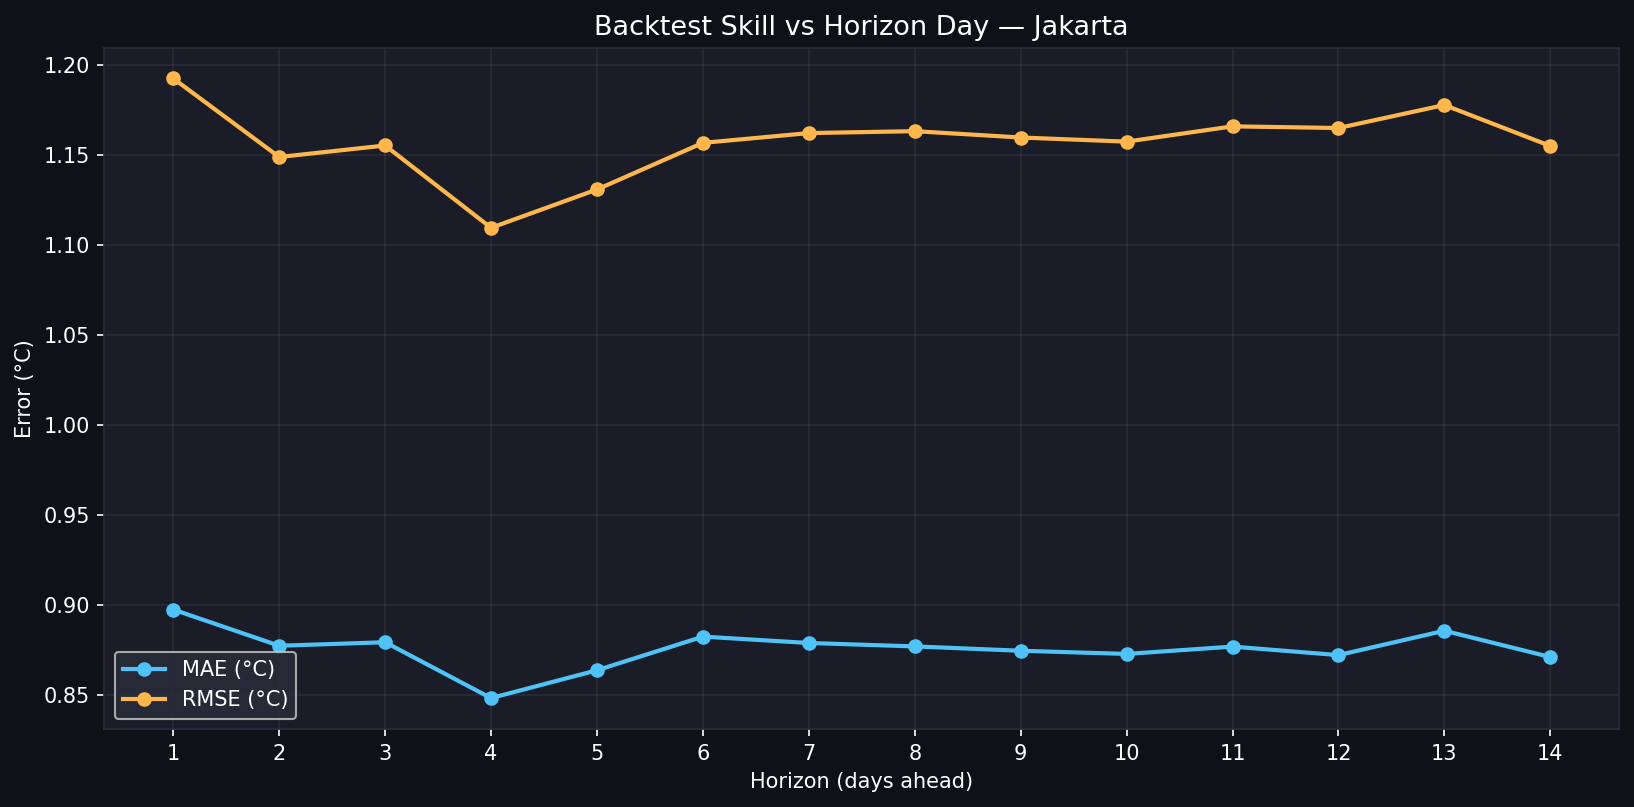

2026-08-30 11:41:58,653 - INFO - [Plot] Forecast-fan chart saved to: result\jakarta_forecast_fan.png


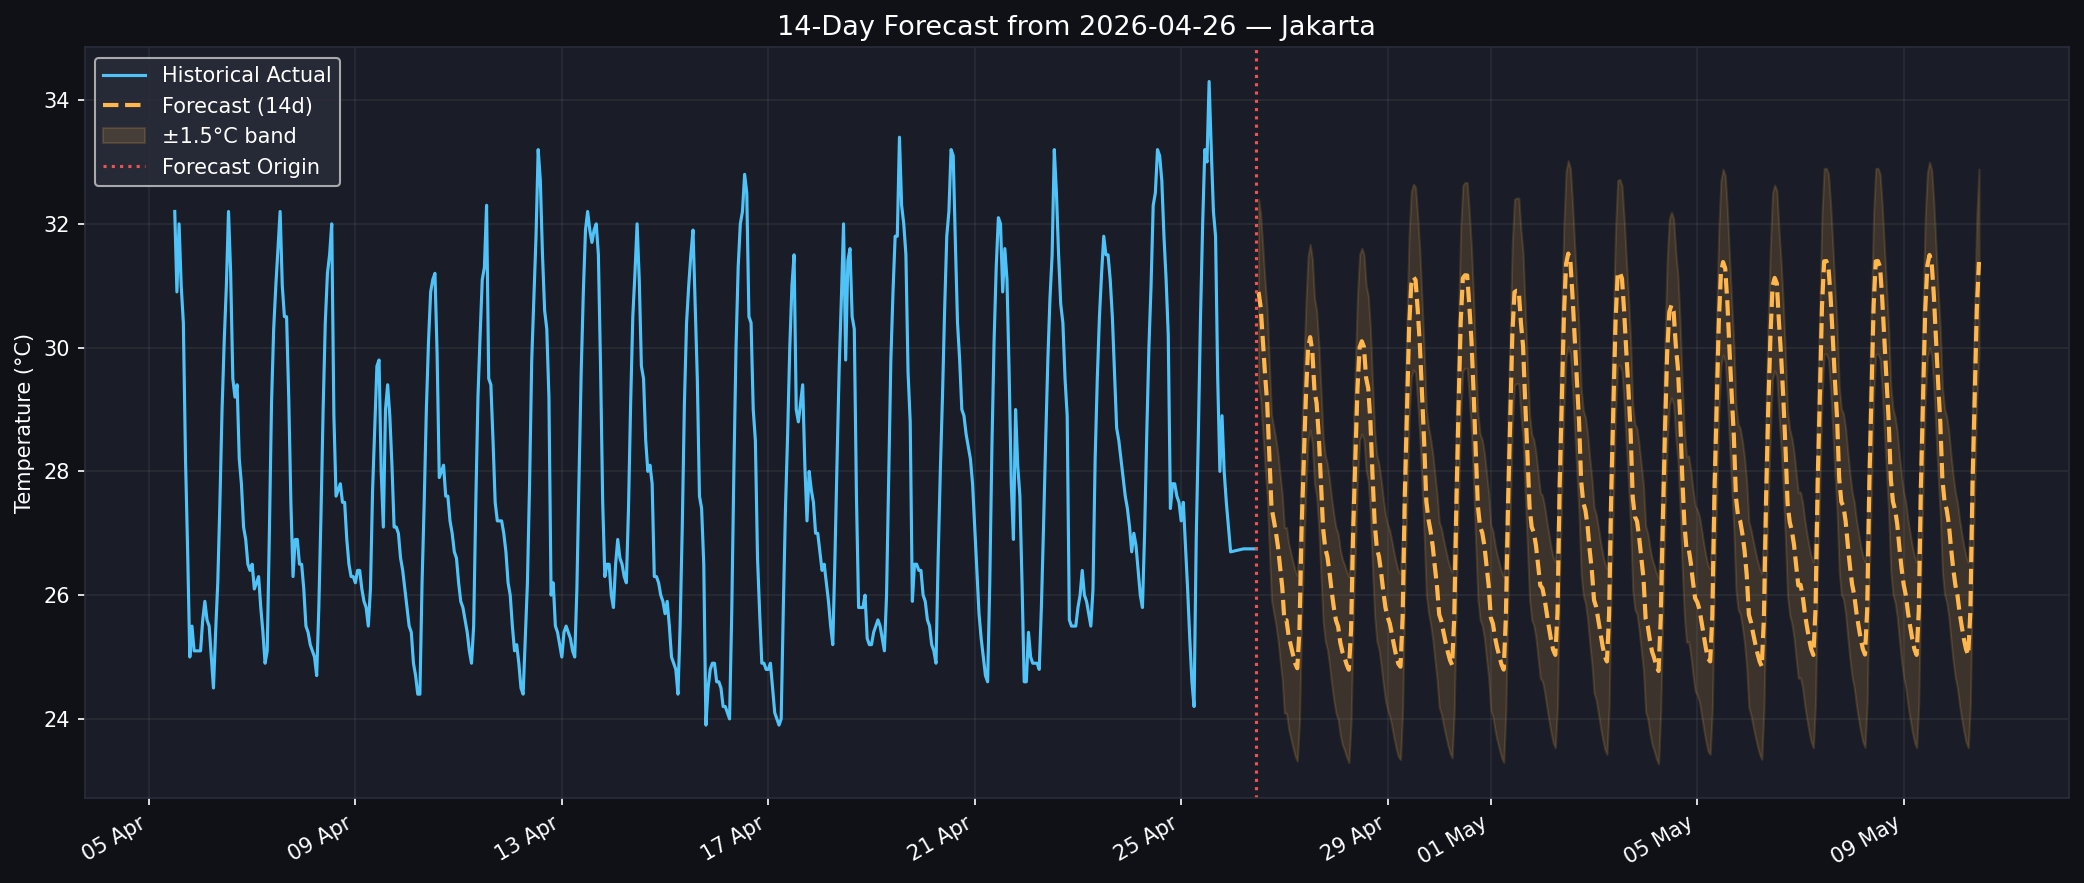

In [10]:
for name, res in results.items():
    mdl = res["model"]

    img_skill = mdl.plot_skill_by_horizon(res["backtest"], save=True, show=CONFIG["SHOW_PLOTS"])
    if img_skill and os.path.exists(img_skill):
        display(Image(img_skill))

    if not res["live"].empty:
        img_fan = mdl.plot_forecast_fan(datasets[name]["actual"], res["live"], save=True, show=CONFIG["SHOW_PLOTS"])
        if img_fan and os.path.exists(img_fan):
            display(Image(img_fan))

## STEP 09 - Feature Importance

2026-08-30 11:41:59,068 - INFO - [Plot] Feature importance chart saved to: result\jakarta_feature_importance.png


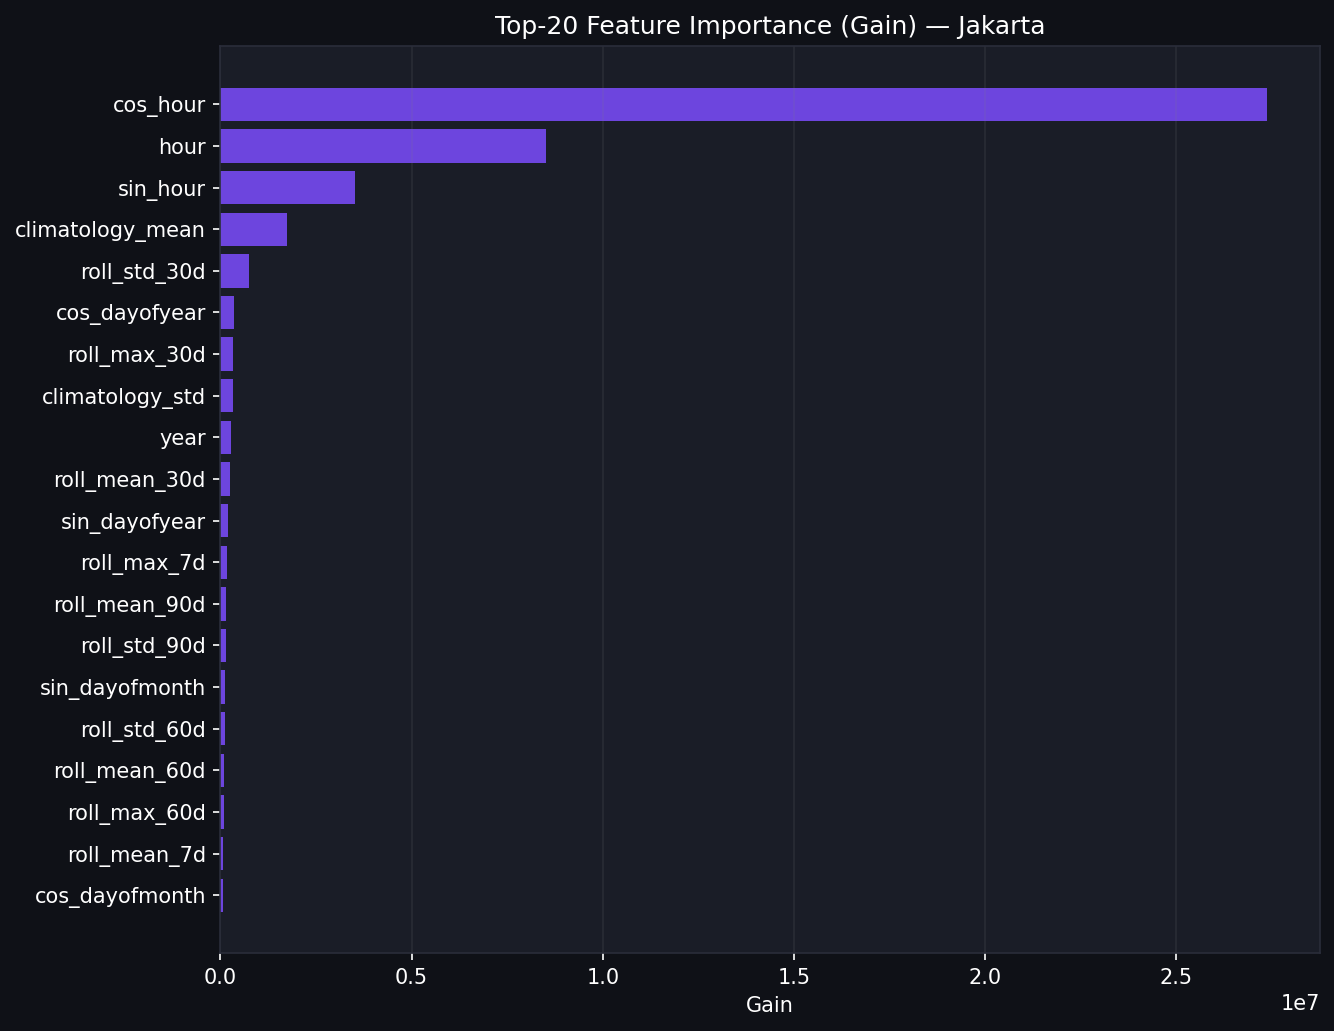

In [11]:
first_station = CONFIG["STATIONS"][0]
mdl = results[first_station]["model"]

img_path = mdl.plot_feature_importance(top_n=20, save=True, show=CONFIG["SHOW_PLOTS"])
if img_path and os.path.exists(img_path):
    display(Image(img_path))

## STEP 10 - Save Model

In [12]:
if CONFIG["SAVE_MODEL"]:
    for name, res in results.items():
        path = res["model"].save_model()
        print(f"  ok  {name} saved -> {path}")
else:
    print("SAVE_MODEL=False, model not saved.")

2026-08-30 11:41:59,154 - INFO - [Model] Saved to: result\lgbm_jakarta.pkl


  ok  Jakarta saved -> result\lgbm_jakarta.pkl


## Optional - Run via Full Orchestrator

Runs the entire pipeline at once through `main_bmkg_forecast.run_pipeline()`, for re-running with a different configuration without repeating each cell above.

In [13]:
# from main_bmkg_forecast import run_pipeline
#
# custom_config = {
#     "END_TRAIN":              None,
#     "TARGET_DATE":            None,
#     "STATIONS":               ["Bandung", "Surabaya"],
#     "HISTORICAL_START":       "2020-01-01",
#     "FORCE_REFRESH":          False,
#     "SAVE_MODEL":             True,
#     "SHOW_PLOTS":             False,
#     "FORECAST_HORIZON_HOURS": 336,
#     "ORIGIN_STRIDE_HOURS":    24,
# }
#
# results_alt = run_pipeline(custom_config)